In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
data = pd.read_csv("new_insurance_data.csv")

In [3]:
data.head(40)

,age,sex,bmi,children,smoker,Claim_Amount,past_consultations,num_of_steps,Hospital_expenditure,NUmber_of_past_hospitalizations,Anual_Salary,region,charges
0,18.0,male,23.210,0.0,no,29087.543130,17.0,715428.0,4.720921e+06,0.0,5.578497e+07,southeast,1121.87390
1,18.0,male,30.140,0.0,no,39053.674370,7.0,699157.0,4.329832e+06,0.0,1.370089e+07,southeast,1131.50660
2,18.0,male,33.330,0.0,no,39023.627590,19.0,702341.0,6.884861e+06,0.0,7.352311e+07,southeast,1135.94070
3,18.0,male,33.660,0.0,no,28185.393320,11.0,700250.0,4.274774e+06,0.0,7.581968e+07,southeast,1136.39940
4,18.0,male,34.100,0.0,no,14697.859410,16.0,711584.0,3.787294e+06,0.0,2.301232e+07,southeast,1137.01100
5,18.0,male,34.430,0.0,no,26488.339120,20.0,717162.0,3.696161e+06,0.0,NaN,southeast,1137.46970
6,18.0,male,37.290,0.0,no,33217.365480,13.0,699159.0,8.765292e+05,0.0,6.906067e+07,southeast,1141.44510
7,18.0,male,41.140,0.0,no,46770.585330,12.0,706423.0,4.486741e+06,0.0,9.719378e+07,southeast,1146.79660
8,18.0,male,43.010,0.0,no,9715.650411,17.0,NaN,9.216440e+06,0.0,5.888197e+07,southeast,1149.39590
9,18.0,male,53.130,0.0,no,17046.585150,19.0,704425.0,1.458972e+06,0.0,9.426182e+07,southeast,1163.46270


In [4]:
data.shape

(1338, 13)

In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 13 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   age                              1329 non-null   float64
 1   sex                              1338 non-null   object 
 2   bmi                              1335 non-null   float64
 3   children                         1333 non-null   float64
 4   smoker                           1338 non-null   object 
 5   Claim_Amount                     1324 non-null   float64
 6   past_consultations               1332 non-null   float64
 7   num_of_steps                     1335 non-null   float64
 8   Hospital_expenditure             1334 non-null   float64
 9   NUmber_of_past_hospitalizations  1336 non-null   float64
 10  Anual_Salary                     1332 non-null   float64
 11  region                           1338 non-null   object 
 12  charges             

In [6]:
data.columns

Index(['age', 'sex', 'bmi', 'children', 'smoker', 'Claim_Amount',
       'past_consultations', 'num_of_steps', 'Hospital_expenditure',
       'NUmber_of_past_hospitalizations', 'Anual_Salary', 'region', 'charges'],
      dtype='object')

In [7]:
data.isnull().sum()

age                                 9
sex                                 0
bmi                                 3
children                            5
smoker                              0
Claim_Amount                       14
past_consultations                  6
num_of_steps                        3
Hospital_expenditure                4
NUmber_of_past_hospitalizations     2
Anual_Salary                        6
region                              0
charges                             0
dtype: int64

In [8]:

# Fill numerical columns with median
num_cols = data.select_dtypes(include=['float64']).columns

for col in num_cols:
    data[col].fillna(data[col].median(), inplace=True)


/var/folders/6b/54v1k5rn14q5ht02gj4y6lcm0000gn/T/ipykernel_2456/3951379152.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data[col].fillna(data[col].median(), inplace=True)


In [9]:
data.isnull().sum()

age                                0
sex                                0
bmi                                0
children                           0
smoker                             0
Claim_Amount                       0
past_consultations                 0
num_of_steps                       0
Hospital_expenditure               0
NUmber_of_past_hospitalizations    0
Anual_Salary                       0
region                             0
charges                            0
dtype: int64

In [10]:
data.duplicated().sum()

0

In [11]:
data['charges'].describe()

count     1338.000000
mean     13270.422265
std      12110.011237
min       1121.873900
25%       4740.287150
50%       9382.033000
75%      16639.912515
max      63770.428010
Name: charges, dtype: float64

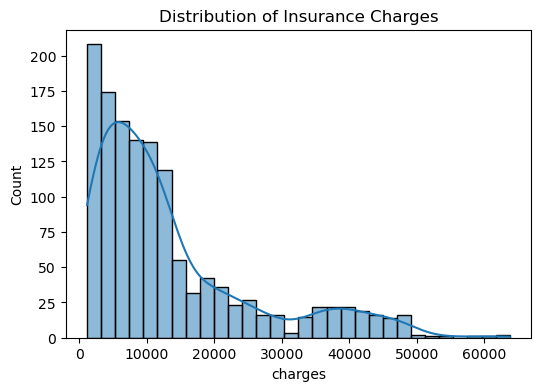

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,4))
sns.histplot(data['charges'], kde=True)
plt.title("Distribution of Insurance Charges")
plt.show()

In [13]:
# Find categorical columns
categorical_cols = data.select_dtypes(include=['object']).columns

categorical_cols

Index(['sex', 'smoker', 'region'], dtype='object')

In [14]:
for col in categorical_cols:
    print(f"{col}:", data[col].unique())

sex: ['male' 'female']
smoker: ['no' 'yes']
region: ['southeast' 'southwest' 'northwest' 'northeast']


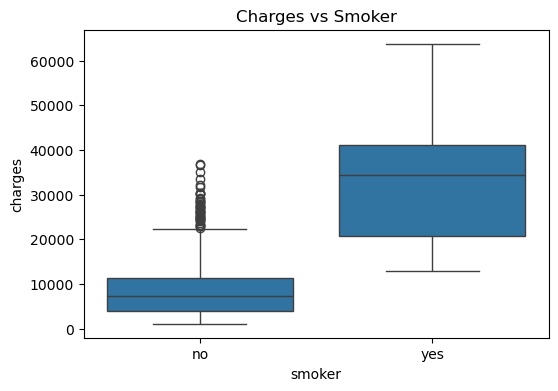

In [15]:
plt.figure(figsize=(6,4))
sns.boxplot(x='smoker', y='charges', data=data)
plt.title("Charges vs Smoker")
plt.show()

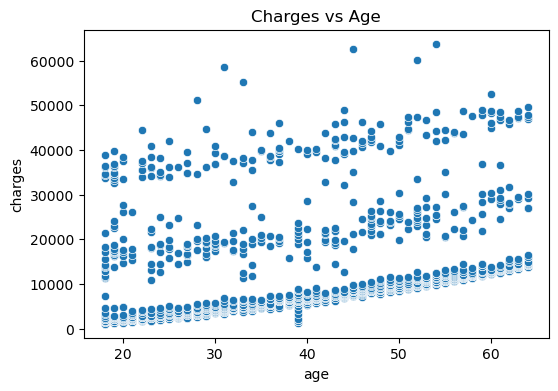

In [16]:
plt.figure(figsize=(6,4))
sns.scatterplot(x='age', y='charges', data=data)
plt.title("Charges vs Age")
plt.show()

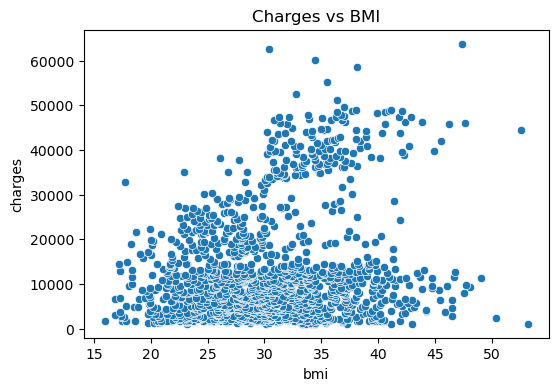

In [17]:
plt.figure(figsize=(6,4))
sns.scatterplot(x='bmi', y='charges', data=data)
plt.title("Charges vs BMI")
plt.show()

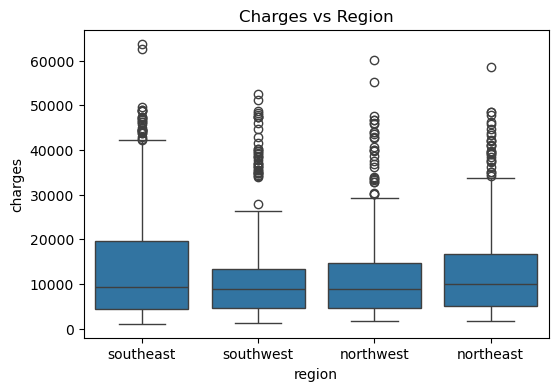

In [18]:
plt.figure(figsize=(6,4))
sns.boxplot(x='region', y='charges', data=data)
plt.title("Charges vs Region")
plt.show()

In [19]:
# ==================================
# ENCODE CATEGORICAL VARIABLES
# ==================================

# Binary Encoding
data['sex'] = data['sex'].map({'male': 0, 'female': 1})
data['smoker'] = data['smoker'].map({'no': 0, 'yes': 1})

# One-Hot Encoding for region
data = pd.get_dummies(data, columns=['region'], drop_first=True)



In [20]:

data.head()

,age,sex,bmi,children,smoker,Claim_Amount,past_consultations,num_of_steps,Hospital_expenditure,NUmber_of_past_hospitalizations,Anual_Salary,charges,region_northwest,region_southeast,region_southwest
0,18.0,0,23.21,0.0,0,29087.54313,17.0,715428.0,4720920.992,0.0,55784970.05,1121.8739,False,True,False
1,18.0,0,30.14,0.0,0,39053.67437,7.0,699157.0,4329831.676,0.0,13700885.19,1131.5066,False,True,False
2,18.0,0,33.33,0.0,0,39023.62759,19.0,702341.0,6884860.774,0.0,73523107.27,1135.9407,False,True,False
3,18.0,0,33.66,0.0,0,28185.39332,11.0,700250.0,4274773.550,0.0,75819679.60,1136.3994,False,True,False
4,18.0,0,34.10,0.0,0,14697.85941,16.0,711584.0,3787293.921,0.0,23012320.01,1137.0110,False,True,False


In [21]:
data.shape

(1338, 15)

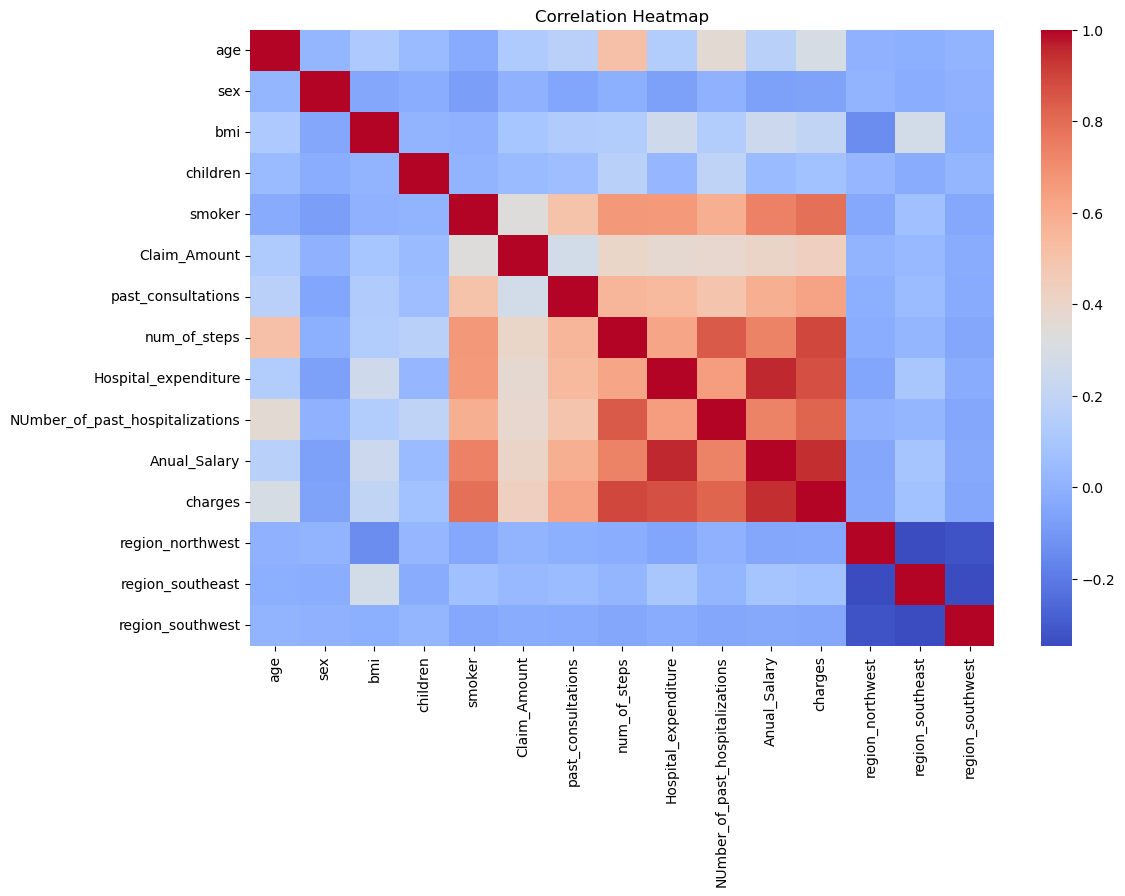

In [22]:
plt.figure(figsize=(12,8))
sns.heatmap(data.corr(), cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

In [23]:
X = data.drop("charges", axis=1)
y = data["charges"]

print("Feature shape:", X.shape)
print("Target shape:", y.shape)

Feature shape: (1338, 14)
Target shape: (1338,)


In [24]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training set:", X_train.shape)
print("Testing set:", X_test.shape)

Training set: (1070, 14)
Testing set: (268, 14)


In [25]:
# ==================================
# IMPORT ALL REGRESSION MODELS
# ==================================

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.neighbors import KNeighborsRegressor

# ==================================
# IMPORT REGRESSION METRICS
# ==================================

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

In [26]:
# ==================================
# TRAIN MULTIPLE MODELS WITH MORE METRICS
# ==================================

models = {
    "Linear Regression": LinearRegression(),
    "Decision Tree": DecisionTreeRegressor(random_state=42),
    "Random Forest": RandomForestRegressor(random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(random_state=42),
    "KNN": KNeighborsRegressor()
}

results = []

n = X_test.shape[0]       # number of samples
p = X_test.shape[1]       # number of features

for name, model in models.items():
    model.fit(X_train, y_train)
    predictions = model.predict(X_test)
    
    mae = mean_absolute_error(y_test, predictions)
    mse = mean_squared_error(y_test, predictions)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, predictions)
    
    # Adjusted R2
    adj_r2 = 1 - (1 - r2) * (n - 1) / (n - p - 1)
    
    results.append([name, mae, mse, rmse, r2, adj_r2])

results_df = pd.DataFrame(
    results,
    columns=["Model", "MAE", "MSE", "RMSE", "R2 Score", "Adjusted R2"]
)

results_df.sort_values(by="R2 Score", ascending=False)

,Model,MAE,MSE,RMSE,R2 Score,Adjusted R2
3,Gradient Boosting,474.256998,6.130704e+05,782.988093,0.996165,0.995953
2,Random Forest,454.460170,1.823544e+06,1350.386540,0.988593,0.987962
1,Decision Tree,592.585861,2.837585e+06,1684.513297,0.982250,0.981268
0,Linear Regression,940.129002,4.408716e+06,2099.694348,0.972422,0.970896
4,KNN,1280.174303,4.880033e+06,2209.079689,0.969474,0.967785


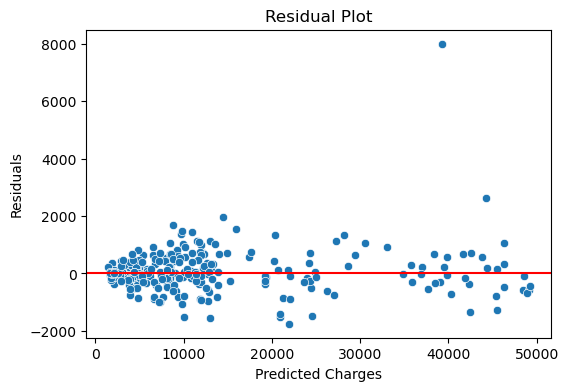

In [27]:
# Best model
best_model = GradientBoostingRegressor(random_state=42)
best_model.fit(X_train, y_train)

pred = best_model.predict(X_test)

residuals = y_test - pred

plt.figure(figsize=(6,4))
sns.scatterplot(x=pred, y=residuals)
plt.axhline(0, color='red')
plt.xlabel("Predicted Charges")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.show()

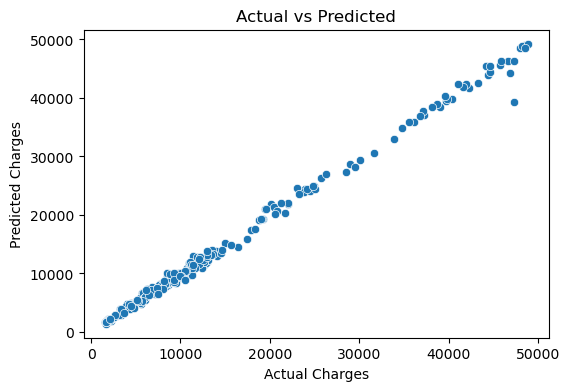

In [28]:
plt.figure(figsize=(6,4))
sns.scatterplot(x=y_test, y=pred)
plt.xlabel("Actual Charges")
plt.ylabel("Predicted Charges")
plt.title("Actual vs Predicted")
plt.show()

In [29]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": best_model.feature_importances_
}).sort_values(by="Importance", ascending=False)

importance

,Feature,Importance
7,num_of_steps,4.203551e-01
9,NUmber_of_past_hospitalizations,3.679027e-01
10,Anual_Salary,1.421201e-01
8,Hospital_expenditure,6.799357e-02
0,age,1.213717e-03
4,smoker,1.390114e-04
2,bmi,7.779644e-05
5,Claim_Amount,7.603887e-05
6,past_consultations,6.871826e-05
3,children,2.777239e-05


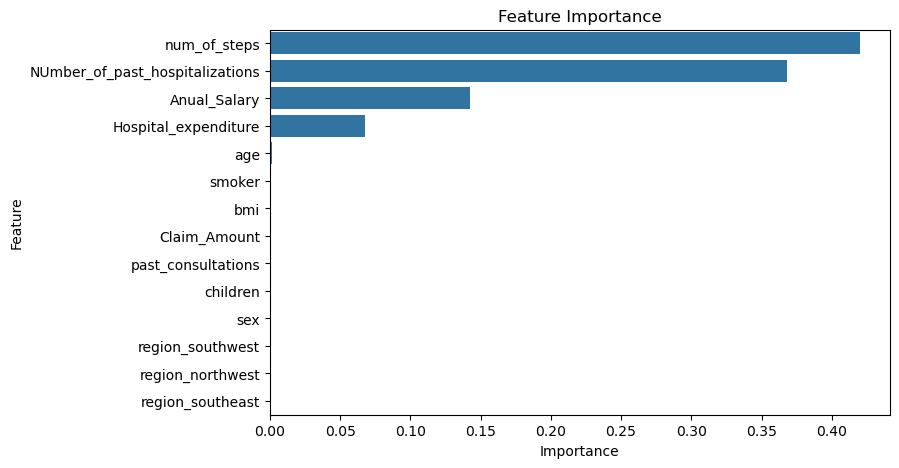

In [30]:
plt.figure(figsize=(8,5))
sns.barplot(x="Importance", y="Feature", data=importance)
plt.title("Feature Importance")
plt.show()

In [34]:
import pickle

pickle.dump(model, open("insurance_model.pkl", "wb"))

# save feature order
feature_order = X.columns.tolist()
pickle.dump(feature_order, open("feature_order.pkl", "wb"))

print("Model and feature order saved successfully.")

Model and feature order saved successfully.
